# Fraud Risk Scoring and LLM-Assisted Analyst Explanation System

This notebook extends a fraud classification project with threshold policy analysis, SHAP local explanations, and analyst-facing LLM notes. The Random Forest produces the fraud score; the LLM only summarizes verified model evidence.

## 1. Setup

In [2]:
# Run this once if these packages are not installed:
# pip install shap openai

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from openai import OpenAI

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, average_precision_score,
    confusion_matrix
)

DATA_PATH = Path("../data/raw/creditcard.csv")
OUTPUT_DIR = Path("../reports/llm_explanations")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


Matplotlib is building the font cache; this may take a moment.
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load and profile data

Put Kaggle `creditcard.csv` under `data/raw/creditcard.csv` before running.

In [3]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
display(df.head())

print("Fraud count:")
display(df["Class"].value_counts())

print("Fraud rate:")
print(df["Class"].mean())

print("Missing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))


(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Fraud count:


Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate:
0.001727485630620034
Missing values:


Time      0
V16       0
Amount    0
V28       0
V27       0
V26       0
V25       0
V24       0
V23       0
V22       0
dtype: int64

## 3. Train/test split

In [4]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


(227845, 30) (56962, 30)


## 4. Train baseline models

In [5]:
# Use the same model settings as the original risk-scoring notebook.
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test_scaled[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf
}

results = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        scores = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        scores = model.predict_proba(X_test)[:, 1]

    preds = (scores >= 0.5).astype(int)

    results[name] = {
        "model": model,
        "scores": scores,
        "precision@0.5": precision_score(y_test, preds, zero_division=0),
        "recall@0.5": recall_score(y_test, preds, zero_division=0),
        "PR-AUC": average_precision_score(y_test, scores)
    }

pd.DataFrame(results).T


,model,scores,precision@0.5,recall@0.5,PR-AUC
Logistic Regression,"LogisticRegression(class_weight='balanced', ma...","[0.005842174994370873, 0.06918075390918371, 0....",0.060976,0.918367,0.715912
Random Forest,"(DecisionTreeClassifier(max_depth=8, max_featu...","[0.006695781656411929, 0.01375194306438498, 0....",0.648438,0.846939,0.799998


## 5. Threshold policy table

This is the most important business-facing section. It shows how the selected threshold affects review workload and missed fraud.

In [6]:
def threshold_policy_table(y_true, scores, thresholds, amount_series=None):
    rows = []
    y_true = np.array(y_true)
    scores = np.array(scores)
    if amount_series is None:
        amount_series = np.zeros(len(y_true))
    amount_series = np.array(amount_series)

    for t in thresholds:
        pred = (scores >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        review_count = int(pred.sum())
        missed_fraud_amount = float(amount_series[(y_true == 1) & (pred == 0)].sum())

        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "true_positives": int(tp),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "review_workload": review_count,
            "review_rate": review_count / len(y_true),
            "missed_fraud_amount": missed_fraud_amount
        })
    return pd.DataFrame(rows)

best_model_name = "Random Forest"
best_scores = results[best_model_name]["scores"]
thresholds = [0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.90]

policy = threshold_policy_table(
    y_test, 
    best_scores, 
    thresholds, 
    amount_series=X_test["Amount"] if "Amount" in X_test.columns else None
)

display(policy)
policy.to_csv(OUTPUT_DIR / "threshold_policy_table.csv", index=False)


,threshold,precision,recall,true_positives,false_positives,false_negatives,review_workload,review_rate,missed_fraud_amount
0,0.05,0.013130,0.938776,92,6915,6,7007,0.123012,137.71
1,0.10,0.042110,0.928571,91,2070,7,2161,0.037938,657.61
2,0.20,0.158559,0.897959,88,467,10,555,0.009743,1822.71
3,0.30,0.321033,0.887755,87,184,11,271,0.004758,1826.50
4,0.50,0.648438,0.846939,83,45,15,128,0.002247,3828.23
5,0.70,0.835165,0.775510,76,15,22,91,0.001598,4421.44
6,0.90,0.846154,0.673469,66,12,32,78,0.001369,5295.02


## 6. Plot threshold tradeoff

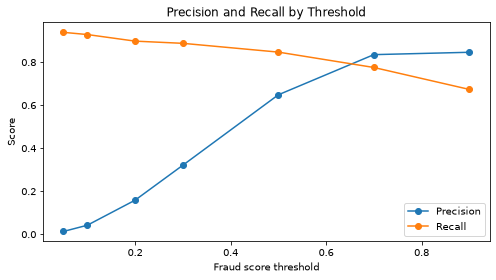

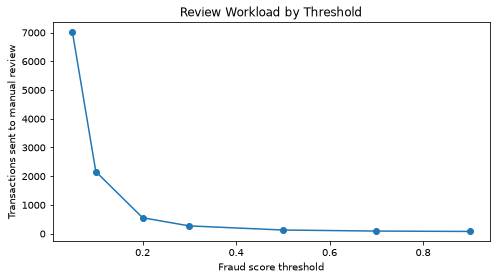

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(policy["threshold"], policy["precision"], marker="o", label="Precision")
plt.plot(policy["threshold"], policy["recall"], marker="o", label="Recall")
plt.xlabel("Fraud score threshold")
plt.ylabel("Score")
plt.title("Precision and Recall by Threshold")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "precision_recall_by_threshold.png", dpi=200)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(policy["threshold"], policy["review_workload"], marker="o")
plt.xlabel("Fraud score threshold")
plt.ylabel("Transactions sent to manual review")
plt.title("Review Workload by Threshold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "review_workload_by_threshold.png", dpi=200)
plt.show()


## 7. Select transactions for analyst explanation

This section prepares structured inputs for analyst-facing explanations.

In [8]:
# The earlier threshold analysis found 0.30 to be the lowest-cost option
# under this project's simple cost assumptions.
selected_threshold = 0.30

test_output = X_test.copy()
test_output["true_label"] = y_test.values
test_output["fraud_score"] = best_scores
test_output["decision"] = np.where(test_output["fraud_score"] >= selected_threshold, "Review", "Pass")
test_output["transaction_id"] = test_output.index

flagged = test_output[test_output["decision"] == "Review"].copy()
flagged = flagged.sort_values("fraud_score", ascending=False).head(50)
flagged = flagged.reset_index(drop=True)

display(flagged[["transaction_id", "Amount", "fraud_score", "decision", "true_label"]].head())
flagged.to_csv(OUTPUT_DIR / "flagged_transactions.csv", index=False)


,transaction_id,Amount,fraud_score,decision,true_label
0,77348,0.01,0.999398,Review,1
1,150663,316.06,0.999397,Review,1
2,42696,88.23,0.999396,Review,1
3,42009,112.33,0.999395,Review,1
4,143728,1.00,0.999394,Review,1


## 8. Build local risk signals with SHAP

Global feature importance says which features matter across the full dataset. Here we use SHAP to find which features pushed up the fraud score for each flagged transaction. Because `V1` to `V28` are anonymized, we report them only as model signals and do not invent merchant, identity, device, or location details.

In [9]:
rf_model = results["Random Forest"]["model"]
model_columns = list(X_train.columns)

# SHAP gives a local contribution for every feature in every transaction.
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(flagged[model_columns])

# SHAP versions return classification results in two common formats.
if isinstance(shap_values, list):
    fraud_shap_values = shap_values[1]
elif len(shap_values.shape) == 3:
    fraud_shap_values = shap_values[:, :, 1]
else:
    fraud_shap_values = shap_values

local_signals = []
signal_features = []

for i in range(len(flagged)):
    contributions = pd.Series(fraud_shap_values[i], index=model_columns)
    positive_contributions = contributions[contributions > 0]
    top_three = positive_contributions.sort_values(ascending=False).head(3)

    feature_names = list(top_three.index)
    signal_features.append(", ".join(feature_names))

    signal_text = []
    for feature in feature_names:
        feature_value = flagged.loc[i, feature]
        shap_value = top_three[feature]
        signal_text.append(
            f"{feature}={feature_value:.3f} (SHAP contribution +{shap_value:.3f})"
        )

    local_signals.append("; ".join(signal_text))

flagged["signal_features"] = signal_features
flagged["local_signals"] = local_signals

explanation_input = flagged[[
    "transaction_id", "Amount", "fraud_score", "decision",
    "signal_features", "local_signals"
]].copy()
explanation_input["threshold"] = selected_threshold

display(explanation_input.head())
explanation_input.to_csv(OUTPUT_DIR / "flagged_transaction_explanations_input.csv", index=False)


,transaction_id,Amount,fraud_score,decision,signal_features,local_signals,threshold
0,77348,0.01,0.999398,Review,"V14, V10, V12",V14=-6.174 (SHAP contribution +0.142); V10=-4....,0.3
1,150663,316.06,0.999397,Review,"V14, V10, V12",V14=-14.094 (SHAP contribution +0.127); V10=-1...,0.3
2,42696,88.23,0.999396,Review,"V14, V10, V12",V14=-14.107 (SHAP contribution +0.131); V10=-1...,0.3
3,42009,112.33,0.999395,Review,"V14, V10, V17",V14=-8.226 (SHAP contribution +0.127); V10=-4....,0.3
4,143728,1.00,0.999394,Review,"V14, V10, V4",V14=-8.604 (SHAP contribution +0.134); V10=-6....,0.3


## 9. Generate analyst-facing explanations with an LLM

The Random Forest still makes the fraud decision. The LLM only turns verified model evidence into a short note for an analyst. Before running this cell, save your API key in the `OPENAI_API_KEY` environment variable. The example generates 10 explanations to limit API cost.

### OpenAI API setup

Before running the LLM section, set your OpenAI API key in the `OPENAI_API_KEY` environment variable.

For example, in Terminal:

```bash
export OPENAI_API_KEY="your_api_key_here"

In [13]:
client = OpenAI()

def generate_explanation(row):
    prompt = f"""
Write a short explanation for a fraud analyst. Use only the facts below.
Do not invent a merchant, cardholder, device, IP address, identity, or location.
Do not claim that an anonymized feature has a real-world meaning.
Mention that the transaction needs manual review, give the score and threshold,
and name the three local model signals. Copy the numbers exactly as shown.
Write 2 or 3 simple sentences.

Transaction ID: {row['transaction_id']}
Fraud score: {row['fraud_score']:.3f}
Review threshold: {row['threshold']:.2f}
Transaction amount: {row['Amount']:.2f}
Local model signals: {row['local_signals']}
"""

    response = client.responses.create(
        model="gpt-5-mini",
        input=prompt,
        store=False
    )
    return response.output_text.strip()

explanations = explanation_input.head(10).copy()
llm_outputs = []

for i in range(len(explanations)):
    explanation = generate_explanation(explanations.iloc[i])
    llm_outputs.append(explanation)

explanations["analyst_explanation"] = llm_outputs

display(explanations[["transaction_id", "fraud_score", "decision", "analyst_explanation"]])
explanations.to_csv(OUTPUT_DIR / "analyst_explanations.csv", index=False)


,transaction_id,fraud_score,decision,analyst_explanation
0,77348,0.999398,Review,Transaction 77348 requires manual review; frau...
1,150663,0.999397,Review,Transaction 150663 (amount 316.06) has fraud s...
2,42696,0.999396,Review,Transaction 42696 (amount 88.23) requires manu...
3,42009,0.999395,Review,Transaction 42009 for amount 112.33 needs manu...
4,143728,0.999394,Review,Transaction 143728 requires manual review; fra...
5,251904,0.999391,Review,Transaction 251904 (amount 94.82) needs manual...
6,42769,0.999391,Review,"Transaction 42769 has fraud score 0.999, which..."
7,42756,0.999391,Review,Transaction 42756 needs manual review; fraud s...
8,150647,0.999388,Review,Transaction ID 150647 has fraud score 0.999 wh...
9,150665,0.999386,Review,Transaction ID 150665 (amount 209.65) needs ma...


## 10. Simple faithfulness checks

These checks do not prove that an explanation is perfect. They catch three basic failures: a missing score or threshold, missing local feature names, and unsupported real-world claims. Flagged explanations should still be read manually.

In [14]:
unsupported_terms = [
    "merchant", "cardholder", "device", "ip address",
    "identity", "location", "country", "city"
]

check_rows = []

for i in range(len(explanations)):
    row = explanations.iloc[i]
    text = row["analyst_explanation"].lower()

    score_is_present = f"{row['fraud_score']:.3f}" in text
    threshold_is_present = f"{row['threshold']:.2f}" in text

    feature_names = row["signal_features"].split(", ")
    features_are_present = True
    for feature in feature_names:
        if feature.lower() not in text:
            features_are_present = False

    found_unsupported_term = False
    for term in unsupported_terms:
        if term in text:
            found_unsupported_term = True

    passed = (
        score_is_present
        and threshold_is_present
        and features_are_present
        and not found_unsupported_term
    )

    check_rows.append({
        "transaction_id": row["transaction_id"],
        "score_present": score_is_present,
        "threshold_present": threshold_is_present,
        "local_features_present": features_are_present,
        "unsupported_claim_flag": found_unsupported_term,
        "passed_basic_checks": passed,
        "analyst_explanation": row["analyst_explanation"]
    })

eval_table = pd.DataFrame(check_rows)
display(eval_table)
eval_table.to_csv(OUTPUT_DIR / "llm_explanation_faithfulness_review.csv", index=False)

print("Passed basic checks:", eval_table["passed_basic_checks"].sum(), "out of", len(eval_table))


,transaction_id,score_present,threshold_present,local_features_present,unsupported_claim_flag,passed_basic_checks,analyst_explanation
0,77348,True,True,True,False,True,Transaction 77348 requires manual review; frau...
1,150663,True,True,True,False,True,Transaction 150663 (amount 316.06) has fraud s...
2,42696,True,True,True,False,True,Transaction 42696 (amount 88.23) requires manu...
3,42009,True,True,True,False,True,Transaction 42009 for amount 112.33 needs manu...
4,143728,True,True,True,False,True,Transaction 143728 requires manual review; fra...
5,251904,True,True,True,False,True,Transaction 251904 (amount 94.82) needs manual...
6,42769,True,True,True,False,True,"Transaction 42769 has fraud score 0.999, which..."
7,42756,True,True,True,False,True,Transaction 42756 needs manual review; fraud s...
8,150647,True,True,True,False,True,Transaction ID 150647 has fraud score 0.999 wh...
9,150665,True,True,True,False,True,Transaction ID 150665 (amount 209.65) needs ma...


Passed basic checks: 10 out of 10


## 11. Short project summary for README or interview

In [15]:
summary_text = f'''
Project summary:
I built a fraud classification and risk-scoring pipeline for a highly imbalanced dataset.
I compared Logistic Regression and Random Forest using precision, recall, and PR-AUC, then tested different thresholds to measure missed fraud and manual-review workload.
For flagged transactions, I used SHAP to find the local features that increased each fraud score.
I then sent only the verified score, threshold, amount, and SHAP signals to an LLM to create a short analyst note.
Finally, I ran simple checks for missing evidence and unsupported real-world claims.

Selected model: {best_model_name}
PR-AUC: {results[best_model_name]['PR-AUC']:.3f}
Selected threshold: {selected_threshold}
Flagged transactions prepared for explanation: {len(flagged)}
LLM explanations generated: {len(explanations)}
Explanations passing basic checks: {eval_table['passed_basic_checks'].sum()} out of {len(eval_table)}
'''
print(summary_text)
Path(OUTPUT_DIR / "project_summary.txt").write_text(summary_text)



Project summary:
I built a fraud classification and risk-scoring pipeline for a highly imbalanced dataset.
I compared Logistic Regression and Random Forest using precision, recall, and PR-AUC, then tested different thresholds to measure missed fraud and manual-review workload.
For flagged transactions, I used SHAP to find the local features that increased each fraud score.
I then sent only the verified score, threshold, amount, and SHAP signals to an LLM to create a short analyst note.
Finally, I ran simple checks for missing evidence and unsupported real-world claims.

Selected model: Random Forest
PR-AUC: 0.800
Selected threshold: 0.3
Flagged transactions prepared for explanation: 50
LLM explanations generated: 10
Explanations passing basic checks: 10 out of 10



775